# Peak-Performance Analysis — IROS-workshop pitch sweep

Reduces each policy to a **single representative number per metric** and compares controller
**methods** (`fixed_geo`, `GAS_geo`, `GAS`, `VICES`) across the **grasp-angle** sweep
(`0°, 15°, 30°, 45°`) with **bar charts** (bar = mean, error bar = 95% CI over seeds).

The `USE_EVAL` flag picks how each agent is reduced:

* `USE_EVAL = False` — the agent's **best training checkpoint**: the metric read at the step
  where that agent's *success rate* peaks (training data).
* `USE_EVAL = True` — the agent's **eval run** value (a post-training evaluation; one row/agent).

For each metric — **success rate**, **mean reward**, **average force** — there are four bars:

1. **x = method, bar per grasp angle** (clustered, colored by angle),
2. **x = grasp angle, bar per method** (clustered, colored by method),
3. **aggregated over all runs — one bar per method** (pooled over angles),
4. **aggregated over all runs — one bar per grasp angle** (pooled over methods).

Data loading, styling, colors, reductions and plot building live in `analysis_utils.py`
(shared with `performance_analysis.ipynb`). The wandb download is cached, so downloading in
**either** notebook populates the shared cache for both. Figures save as SVG under
`runs/{FOLDER}/plots/iros_peak_perf/`.

## 1. Imports

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt


# analysis_utils.py sits next to this notebook in iros_workshop_analysis/. Make it
# importable whether the kernel starts here, in data_analysis/, or at the repo root.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (d,
                     os.path.join(d, "iros_workshop_analysis"),
                     os.path.join(d, "data_analysis", "iros_workshop_analysis")):
            if os.path.isfile(os.path.join(cand, "analysis_utils.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import importlib
import analysis_utils as au   # data loading + styling + plotting (single source of truth)

# Re-read analysis_utils.py from disk each run so edits take effect WITHOUT a kernel restart.
importlib.reload(au)

<module 'analysis_utils' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/iros_workshop_analysis/analysis_utils.py'>

## 2. Global parameters

In [2]:
# --- Data source (wandb). Same project/tag as performance_analysis; the download is cached,
# so running EITHER notebook's load cell fills the shared cache for both. Set
# WANDB_PROJECT/WANDB_TAG = None to load a local runs/ subfolder via LOCAL_FOLDER instead.
WANDB_PROJECT = "flat_6d" #"pitch_sweep"
WANDB_TAG     = "sweep_rotOri" #pitch_sweep"
WANDB_ENTITY  = "hur"
LOCAL_FOLDER  = ""   # used only when WANDB_PROJECT/WANDB_TAG are None
FOLDER_NAME   = f"{WANDB_PROJECT}_{WANDB_TAG}" if (WANDB_PROJECT and WANDB_TAG) else LOCAL_FOLDER
FORCE_WANDB_REFRESH = False

# THE FLAG. False -> each agent's BEST training checkpoint (metric at its peak-success step);
#           True  -> each agent's EVAL run value. (Eval runs are downloaded alongside training.)
USE_EVAL = False

# Confidence interval: mean +/- CI_Z * SEM across seeds. 1.96 -> ~95% CI.
CI_Z = 1.96

# Step window cap for the "best" reduction (training data only). None = consider all steps.
XLIM = None

# Metric whose per-agent PEAK defines the "best" checkpoint (ignored when USE_EVAL=True).
SELECTION_METRIC = "Episode / Success rate"

# Per-metric config. `ci_clip` = (min, max) clips the error-bar whiskers (value +/- CI) to
# those limits (bar height untouched) -- e.g. success rate to [0, 1], force to [0, inf).
# `ylim` sets the y-axis (None = auto).
METRICS = {
    "success": dict(tag="Episode / Success rate",       ylabel="Success Rate",
                    ci_clip=(0.0, 1.0),  ylim=(0,1)),
    "reward":  dict(tag="Reward / Total reward (mean)", ylabel="Total Reward",
                    ci_clip=None,        ylim=None),
    "force":   dict(tag="drag_performance/force_mean",  ylabel="Force (N)",
                    ci_clip=(0.0, None), ylim=None),
}

# Output folder, one per analysis notebook: runs/{FOLDER}/plots/iros_peak_perf/{name}.svg
# (re-running overwrites in place; no date stamp).
PLOTS_DIR = os.path.join(au.runs_root(), FOLDER_NAME, "plots", "iros_peak_perf")

# Context object threaded through every figure helper (CI z, output dir, palettes).
STYLE = au.Style(ci_z=CI_Z, xlim=XLIM, plots_dir=PLOTS_DIR)

## 3. Load data

In [3]:
# Download once (cached). include_eval=True mirrors BOTH the training runs (-> runs/{FOLDER}/)
# and the eval runs (-> runs/{FOLDER}_eval/), so a single download here — or in
# performance_analysis — serves the USE_EVAL flag without a second pull.
if WANDB_PROJECT and WANDB_TAG:
    au.download_wandb_data(WANDB_PROJECT, WANDB_TAG, entity=WANDB_ENTITY, root=au.runs_root(),
                           force=FORCE_WANDB_REFRESH, include_eval=True)

DATA_TRAIN = au.load_data(FOLDER_NAME, au.runs_root())

# Eval is optional: only needed when USE_EVAL=True. Load it if the folder is present.
EVAL_FOLDER = f"{FOLDER_NAME}_eval"
_eval_path = os.path.join(au.runs_root(), EVAL_FOLDER)
DATA_EVAL = au.load_data(EVAL_FOLDER, au.runs_root()) if os.path.isdir(_eval_path) else {}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hunter/.netrc.


[wandb-dl] 100 run(s) in hur/flat_6d tagged 'sweep_rotOri': 100 train -> flat_6d_sweep_rotOri/, 0 eval -> flat_6d_sweep_rotOri_eval/
[wandb-dl]   [train] GAS_0: cached (5 seeds), skip
[wandb-dl]   [train] GAS_15: cached (5 seeds), skip
[wandb-dl]   [train] GAS_30: cached (5 seeds), skip
[wandb-dl]   [train] GAS_45: cached (5 seeds), skip
[wandb-dl]   [train] GAS_geo_0: cached (5 seeds), skip
[wandb-dl]   [train] GAS_geo_15: cached (5 seeds), skip
[wandb-dl]   [train] GAS_geo_30: cached (5 seeds), skip
[wandb-dl]   [train] GAS_geo_45: cached (5 seeds), skip
[wandb-dl]   [train] VICES_0: cached (5 seeds), skip
[wandb-dl]   [train] VICES_15: cached (5 seeds), skip
[wandb-dl]   [train] VICES_30: cached (5 seeds), skip
[wandb-dl]   [train] VICES_45: cached (5 seeds), skip
[wandb-dl]   [train] cholesky_0: cached (5 seeds), skip
[wandb-dl]   [train] cholesky_15: cached (5 seeds), skip
[wandb-dl]   [train] cholesky_30: cached (5 seeds), skip
[wandb-dl]   [train] cholesky_45: cached (5 seeds), 

I0000 00:00:1787283408.345752 1201492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787283408.374290 1201492 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787283408.993315 1201492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GAS_0: 5 seed(s) loaded
GAS_15: 5 seed(s) loaded
GAS_30: 5 seed(s) loaded
GAS_45: 5 seed(s) loaded
GAS_geo_0: 5 seed(s) loaded
GAS_geo_15: 5 seed(s) loaded
GAS_geo_30: 5 seed(s) loaded
GAS_geo_45: 5 seed(s) loaded
VICES_0: 5 seed(s) loaded
VICES_15: 5 seed(s) loaded
VICES_30: 5 seed(s) loaded
VICES_45: 5 seed(s) loaded
cholesky_0: 5 seed(s) loaded
cholesky_15: 5 seed(s) loaded
cholesky_30: 5 seed(s) loaded
cholesky_45: 5 seed(s) loaded
fixed_geo_0: 5 seed(s) loaded
fixed_geo_15: 5 seed(s) loaded
fixed_geo_30: 5 seed(s) loaded
fixed_geo_45: 5 seed(s) loaded


## 4. Process data

In [4]:
# Build the pooled views for whichever source USE_EVAL selects, and set the reduction MODE.
COL_TRAIN = au.build_collections(DATA_TRAIN)
COL_EVAL  = au.build_collections(DATA_EVAL) if DATA_EVAL else None

MODE = "eval" if USE_EVAL else "best"
COL  = COL_EVAL if USE_EVAL else COL_TRAIN
if COL is None:
    raise RuntimeError("USE_EVAL=True but no eval data found in runs/{}_eval/. "
                       "Run the load cell with include_eval=True first.".format(FOLDER_NAME))

# Short tag woven into every figure title so the plot says which source it came from.
SRC = "eval" if USE_EVAL else "best-train"
print(f"source: {'EVAL runs' if USE_EVAL else 'BEST training checkpoint (peak ' + SELECTION_METRIC + ')'}")
print("methods:", COL.methods)
print("angles :", COL.angles)

[collections] 5 method(s) x 4 angle(s): methods=['fixed_geo', 'GAS_geo', 'GAS', 'VICES', 'cholesky'], angles=['0', '15', '30', '45']
source: BEST training checkpoint (peak Episode / Success rate)
methods: ['fixed_geo', 'GAS_geo', 'GAS', 'VICES', 'cholesky']
angles : ['0', '15', '30', '45']


## 5. Success rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_method_x_angle.svg


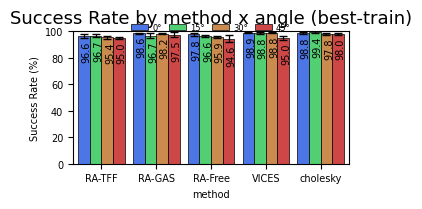

In [5]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate: x-axis = METHOD, one bar per GRASP ANGLE (colored by angle).
LEGEND_POS = "below"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["success"]
fig = au.figure_bars_method_x_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="method", ylabel=m["ylabel"],
                                    title=f'{m["ylabel"]} by method x angle ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "success_method_x_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_angle_x_method.svg


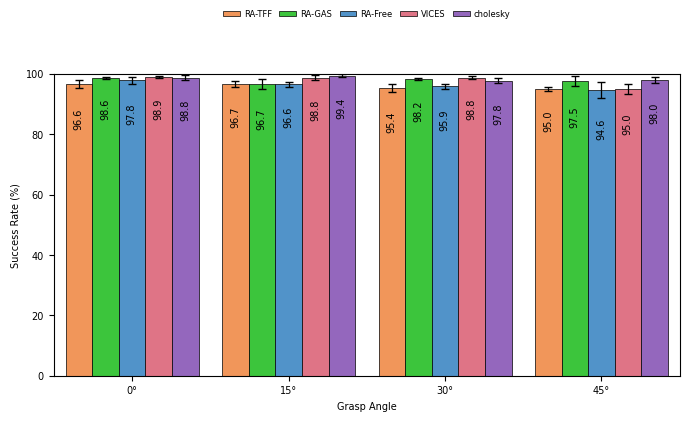

In [24]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate: x-axis = GRASP ANGLE, one bar per METHOD (colored by method).
LEGEND_POS = "below"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["success"]
au.DEFAULT_FIG_WIDTH *= 2
au.DEFAULT_FIG_HEIGHT *=2
#au.BAR_LABEL_OFFSET_ABOVE_SMALL = 0.02
#au.BAR_LABEL_OFFSET_INSIDE_SMALL = 0.02
#au.BAR_LABEL_THRESHOLD_PAD_SMALL = 0.05
fig = au.figure_bars_angle_x_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="Grasp Angle", ylabel=m["ylabel"],
                                    title=None, #f'{m["ylabel"]} by angle x method ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "success_angle_x_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_agg_by_method.svg


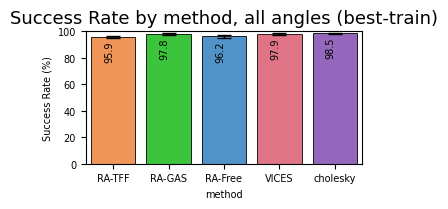

In [7]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate: aggregated over all runs — one bar per METHOD (pooled over grasp angles).
m = METRICS["success"]
fig = au.figure_bars_by_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                               xlabel="method", ylabel=m["ylabel"],
                               title=f'{m["ylabel"]} by method, all angles ({SRC})',
                               ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "success_agg_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_agg_by_angle.svg


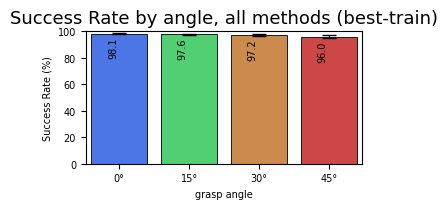

In [8]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate: aggregated over all runs — one bar per GRASP ANGLE (pooled over methods).
m = METRICS["success"]
fig = au.figure_bars_by_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                              xlabel="grasp angle", ylabel=m["ylabel"],
                              title=f'{m["ylabel"]} by angle, all methods ({SRC})',
                              ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "success_agg_by_angle", STYLE)
plt.show()

## 6. Mean reward

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/reward_method_x_angle.svg


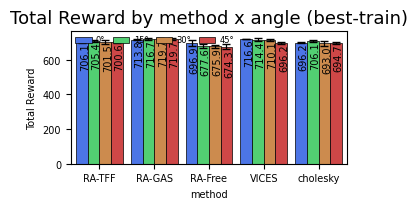

In [9]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward: x-axis = METHOD, one bar per GRASP ANGLE (colored by angle).
LEGEND_POS = "upper left"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["reward"]
fig = au.figure_bars_method_x_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="method", ylabel=m["ylabel"],
                                    title=f'{m["ylabel"]} by method x angle ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "reward_method_x_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/reward_angle_x_method.svg


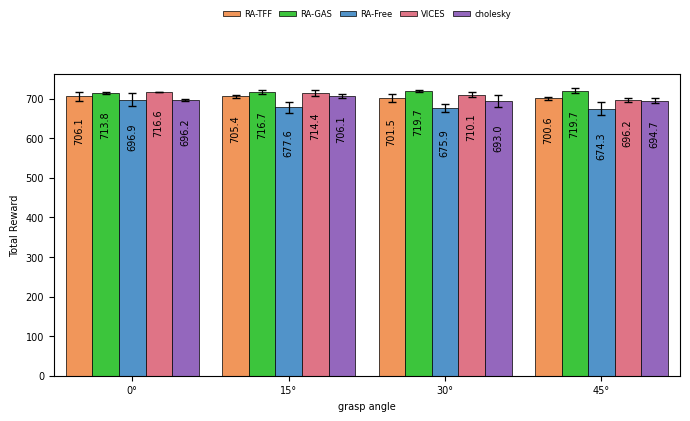

In [25]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)

# Mean reward: x-axis = GRASP ANGLE, one bar per METHOD (colored by method).
LEGEND_POS = "below"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["reward"]
au.DEFAULT_FIG_WIDTH *= 2
au.DEFAULT_FIG_HEIGHT *=2
fig = au.figure_bars_angle_x_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="grasp angle", ylabel=m["ylabel"],
                                    title=None, #f'{m["ylabel"]} by angle x method ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "reward_angle_x_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/reward_agg_by_method.svg


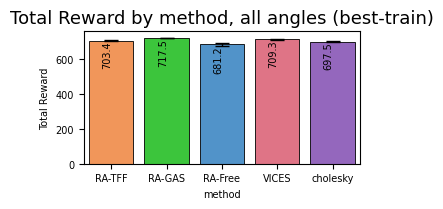

In [11]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward: aggregated over all runs — one bar per METHOD (pooled over grasp angles).
m = METRICS["reward"]
fig = au.figure_bars_by_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                               xlabel="method", ylabel=m["ylabel"],
                               title=f'{m["ylabel"]} by method, all angles ({SRC})',
                               ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "reward_agg_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/reward_agg_by_angle.svg


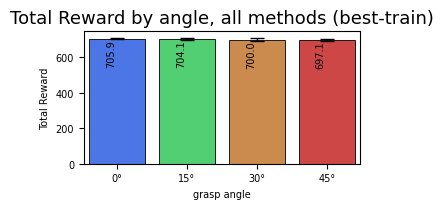

In [12]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward: aggregated over all runs — one bar per GRASP ANGLE (pooled over methods).
m = METRICS["reward"]
fig = au.figure_bars_by_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                              xlabel="grasp angle", ylabel=m["ylabel"],
                              title=f'{m["ylabel"]} by angle, all methods ({SRC})',
                              ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "reward_agg_by_angle", STYLE)
plt.show()

## 7. Average force

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/force_method_x_angle.svg


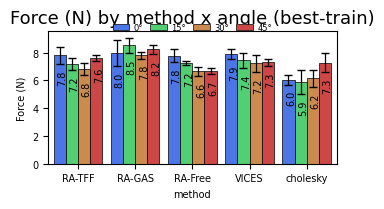

In [13]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force: x-axis = METHOD, one bar per GRASP ANGLE (colored by angle).
LEGEND_POS = "below"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["force"]
fig = au.figure_bars_method_x_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="method", ylabel=m["ylabel"],
                                    title=f'{m["ylabel"]} by method x angle ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "force_method_x_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/force_angle_x_method.svg


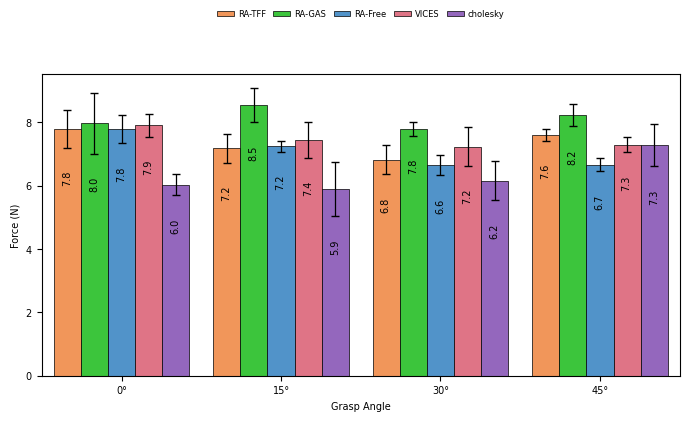

In [26]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force: x-axis = GRASP ANGLE, one bar per METHOD (colored by method).
LEGEND_POS = "below"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
m = METRICS["force"]
au.DEFAULT_FIG_WIDTH *= 2
au.DEFAULT_FIG_HEIGHT *=2
fig = au.figure_bars_angle_x_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="Grasp Angle", ylabel=m["ylabel"],
                                    title=None, #f'{m["ylabel"]} by angle x method ({SRC})',
                                    ylim=m["ylim"], ci_clip=m["ci_clip"], legend_pos=LEGEND_POS)
au.save_figure(fig, "force_angle_x_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/force_agg_by_method.svg


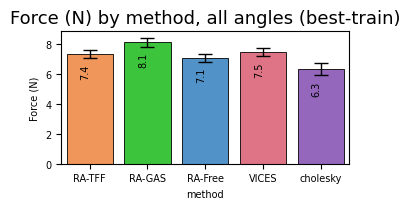

In [15]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force: aggregated over all runs — one bar per METHOD (pooled over grasp angles).
m = METRICS["force"]
fig = au.figure_bars_by_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                               xlabel="method", ylabel=m["ylabel"],
                               title=f'{m["ylabel"]} by method, all angles ({SRC})',
                               ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "force_agg_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/force_agg_by_angle.svg


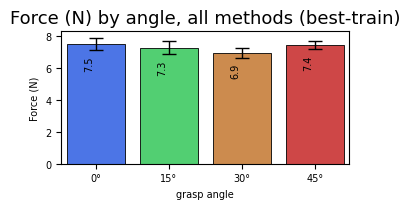

In [16]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force: aggregated over all runs — one bar per GRASP ANGLE (pooled over methods).
m = METRICS["force"]
fig = au.figure_bars_by_angle(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                              xlabel="grasp angle", ylabel=m["ylabel"],
                              title=f'{m["ylabel"]} by angle, all methods ({SRC})',
                              ylim=m["ylim"], ci_clip=m["ci_clip"])
au.save_figure(fig, "force_agg_by_angle", STYLE)
plt.show()

## 8. Success rate vs force (Pareto — one point per run)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/pareto_success_vs_force_per_angle.svg


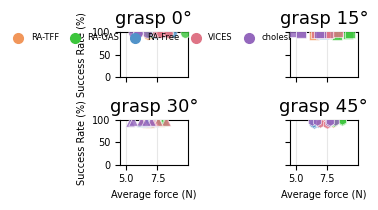

In [17]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate vs force: 2x2 grid, one panel per grasp angle. Each run is a point — COLOR = method,
# SHAPE = grasp angle (circle/square/triangle/hexagon).
SHOW_PARETO_FRONT = False   # flip to False to hide the dashed Pareto-frontier line
LEGEND_POS = "below"       # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
xm, ym = METRICS["force"]["tag"], METRICS["success"]["tag"]
fig = au.figure_pareto_panels(COL, xm, ym, STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                              xlabel="Average force (N)", ylabel=METRICS["success"]["ylabel"],
                              suptitle=None, #f'{METRICS["success"]["ylabel"]} vs force per run — by grasp angle ({SRC})',
                              ncols=2, ylim=METRICS["success"]["ci_clip"], pareto=SHOW_PARETO_FRONT,
                              legend_pos=LEGEND_POS)
au.save_figure(fig, "pareto_success_vs_force_per_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/pareto_success_vs_force_all.svg


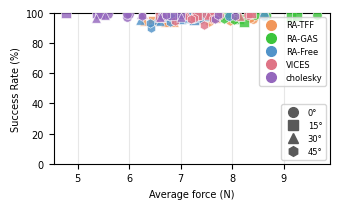

In [18]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate vs force: all runs on one plot — COLOR = method, SHAPE = grasp angle. Shows the overall
# distribution and (optionally) the Pareto frontier over every run.
SHOW_PARETO_FRONT = False   # flip to False to hide the dashed Pareto-frontier line
LEGEND_POS = "box"       # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
xm, ym = METRICS["force"]["tag"], METRICS["success"]["tag"]
fig = au.figure_pareto(COL, xm, ym, STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                       xlabel="Average force (N)", ylabel=METRICS["success"]["ylabel"],
                       title=None, #f'{METRICS["success"]["ylabel"]} vs force per run ({SRC})',
                       ylim=METRICS["success"]["ci_clip"], pareto=SHOW_PARETO_FRONT,
                       legend_pos=LEGEND_POS)
au.save_figure(fig, "pareto_success_vs_force_all", STYLE)
plt.show()

## 9. Mean reward vs force (Pareto — one point per run)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/pareto_reward_vs_force_per_angle.svg


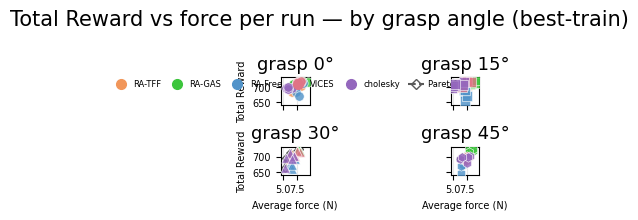

In [19]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward vs force: 2x2 grid, one panel per grasp angle. Each run is a point — COLOR = method,
# SHAPE = grasp angle (circle/square/triangle/hexagon).
SHOW_PARETO_FRONT = True   # flip to False to hide the dashed Pareto-frontier line
LEGEND_POS = "below"       # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
xm, ym = METRICS["force"]["tag"], METRICS["reward"]["tag"]
fig = au.figure_pareto_panels(COL, xm, ym, STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                              xlabel="Average force (N)", ylabel=METRICS["reward"]["ylabel"],
                              suptitle=f'{METRICS["reward"]["ylabel"]} vs force per run — by grasp angle ({SRC})',
                              ncols=2, ylim=METRICS["reward"]["ci_clip"], pareto=SHOW_PARETO_FRONT,
                              legend_pos=LEGEND_POS)
au.save_figure(fig, "pareto_reward_vs_force_per_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/pareto_reward_vs_force_all.svg


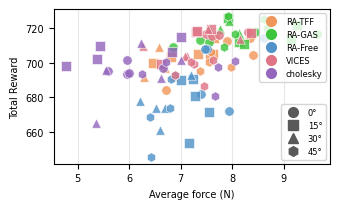

In [20]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward vs force: all runs on one plot — COLOR = method, SHAPE = grasp angle. Shows the overall
# distribution and (optionally) the Pareto frontier over every run.
SHOW_PARETO_FRONT = False   # flip to False to hide the dashed Pareto-frontier line
LEGEND_POS = "box"       # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
xm, ym = METRICS["force"]["tag"], METRICS["reward"]["tag"]
fig = au.figure_pareto(COL, xm, ym, STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                       xlabel="Average force (N)", ylabel=METRICS["reward"]["ylabel"],
                       title=None, #f'{METRICS["reward"]["ylabel"]} vs force per run ({SRC})',
                       ylim=METRICS["reward"]["ci_clip"], pareto=SHOW_PARETO_FRONT,
                       legend_pos=LEGEND_POS)
au.save_figure(fig, "pareto_reward_vs_force_all", STYLE)
plt.show()

## 10. Success combo — curves + angle × method bars + grasp-angle icons

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_combo.svg


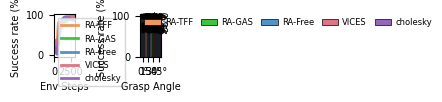

In [21]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Two-column success box: LEFT = success-by-method TRAINING curves (as success_by_method in
# performance_analysis), RIGHT = success by grasp-angle x method bars (as success_angle_x_method
# above). Square PLACEHOLDER icons sit flush to the bottom of the RIGHT panel, centered on each
# grasp angle (side = 20% of the panel height). Drop in real images later with
icon_images=[
    "ang_vis/peg-cartoon_45-deg_profile.png",
    "ang_vis/peg-cartoon_45-deg_profile.png",
    "ang_vis/peg-cartoon_45-deg_profile.png",
    "ang_vis/peg-cartoon_45-deg_profile.png"
    ] 
LEGEND_POS = "upper left"   # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
fig = au.figure_success_combo(COL, STYLE, curve_collections=COL_TRAIN, mode=MODE,
                              selection_metric=SELECTION_METRIC, ci_clip=(0.0, 1.0),
                              left_title=None, #f"Success by method ({SRC})",
                              right_title=None, #f"Success by angle x method ({SRC})",
                              legend_pos=LEGEND_POS, icon_height_frac=0.15, icon_images=None)
au.save_figure(fig, "success_combo", STYLE)
plt.show()

## 11. Success — angle × method (horizontal bars)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_angle_x_method_horizontal.svg


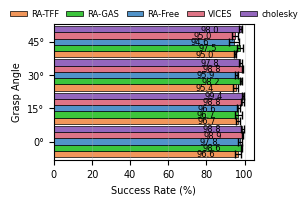

saved /home/hunter/generalized_hybrid_vic_action_space/runs/flat_6d_sweep_rotOri/plots/iros_peak_perf/success_combo_horizontal.svg


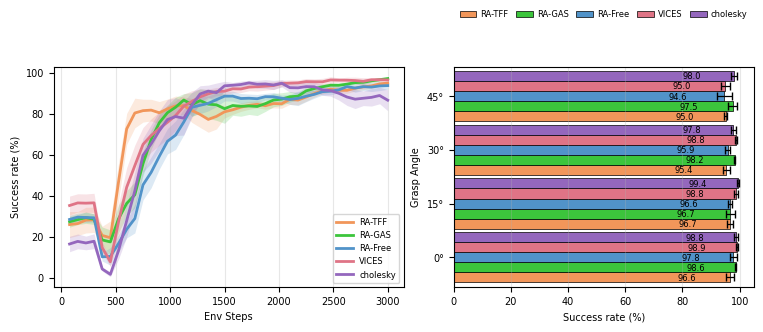

In [22]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Horizontal version of the success "angle x method" bars. BAR_WIDTH / GROUP_GAP are exposed here
# ONLY -- they set each bar's thickness and the space between grasp-angle groups.
LEGEND_POS = "below"    # "box" | "below" | "upper left" | "upper right" | "lower left" | "lower right"
BAR_WIDTH = 0.9       # thickness of each bar
GROUP_GAP = 0.3        # space between grasp-angle groups
BAR_GAP = 0.0         # gap between bars within a grasp-angle group
au.BAR_LABEL_X_OFFSET = -0.05 
#au.BAR_LABEL_GAP_FRAC = 0.02
au.LEGEND_BELOW_OFFSET = -1.4
au.FONT_BAR_LABEL = 6
LABEL_ROTATION = 0      # rotation (deg) of the rate labels
REVERSE_ANGLE_ORDER = True   # False: angles run 0 -> 45 (top to bottom); True: 45 -> 0
FIG_WIDTH = 3.0        # overall plot width (inches) -- lower it so sideways bars are less stretched
FIG_HEIGHT = 2.2       # overall plot height (inches)
m = METRICS["success"]
fig = au.figure_barh_angle_x_method(COL, m["tag"], STYLE, mode=MODE, selection_metric=SELECTION_METRIC,
                                    xlabel="Grasp Angle", ylabel=m["ylabel"],
                                    title=None, #f'{m["ylabel"]} by angle x method, horizontal ({SRC})',
                                    ci_clip=m["ci_clip"], legend_pos=LEGEND_POS,
                                    bar_width=BAR_WIDTH, group_gap=GROUP_GAP, bar_gap=BAR_GAP, label_rotation=LABEL_ROTATION, reverse_categories=REVERSE_ANGLE_ORDER,
                                    figsize=(FIG_WIDTH, FIG_HEIGHT))
au.save_figure(fig, "success_angle_x_method_horizontal", STYLE)
plt.show()

# --- Combo: env-steps success curves (left) + the SAME horizontal bars (right), reusing every knob
# above. Width matches the original combo (16); COMBO_WSPACE adds whitespace between the two panels.
CURVE_WIDTH = 3.5      # width (inches) of the env-steps plot -- FIXED, does not stretch
COMBO_WSPACE = 0.5    # whitespace (inches) between the env-steps plot and the horizontal bars
# The bars panel keeps the SAME size as the standalone above (FIG_WIDTH x FIG_HEIGHT); nothing stretches.
fig2 = au.figure_success_combo_h(COL, STYLE, curve_collections=COL_TRAIN, mode=MODE,
                                 selection_metric=SELECTION_METRIC, ci_clip=m["ci_clip"],
                                 cat_label="Grasp Angle", legend_pos=LEGEND_POS,
                                 bar_width=BAR_WIDTH, group_gap=GROUP_GAP, bar_gap=BAR_GAP,
                                 label_rotation=LABEL_ROTATION, reverse_categories=REVERSE_ANGLE_ORDER,
                                 curve_width=CURVE_WIDTH, bars_width=FIG_WIDTH, panel_height=FIG_HEIGHT,
                                 wspace=COMBO_WSPACE)
au.save_figure(fig2, "success_combo_horizontal", STYLE)
plt.show()